# Telekomünikasyon Müşteri Kaybı Analizi ve Makine Öğrenmesi ile Tahminleme

### 1. Kütüphanelerin İçe Aktarılması

In [1]:
# Gerekli Kütüphaneleri Yükleyelim.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score


### 2. Veri Setinin Yüklenmesi ve Genel Bakış

In [78]:
# Veriyi okuyalım.
df = pd.read_csv('Telco-Customer-Churn.csv')
# Veri hakkında bilgi edinelim
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [79]:
# Total Charges sütunu hakkında bilgi edinelim
df.TotalCharges.info()

<class 'pandas.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype
--------------  -----
7043 non-null   str  
dtypes: str(1)
memory usage: 55.2 KB


### 3. Veri Temizleme ve Tip Dönüşümü

In [80]:
# TotalCharges kolonundaki boşluk (" ") karakterlerini NaN (eksik veri) ile değiştiriyoruz
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
# Artık metin (string) formatından ondalıklı sayı (float) formatına çevirebiliriz
df['TotalCharges'] = df['TotalCharges'].astype(float)
# Eksik değerleri görelim
print("Eksik veri sayısı:\n", df.isnull().sum()[df.isnull().sum() > 0])
# Eksik verileri (11 adet) sistemden çıkartabiliriz çünkü 7043 veri içinde çok küçük bir oran
df.dropna(inplace=True)

Eksik veri sayısı:
 TotalCharges    11
dtype: int64


### 4. Hedef Değişken (Churn) Dağılımının İncelenmesi

In [81]:
# Churn eden (ayrılan) ve etmeyen müşteri sayıları
print(df['Churn'].value_counts())
print("\nYüzdelik Dağılım:\n", df['Churn'].value_counts(normalize=True) * 100)


Churn
No     5163
Yes    1869
Name: count, dtype: int64

Yüzdelik Dağılım:
 Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


### 5. EDA ve Görselleştirmeler

#### 5.1. Genel Kayıp Oranı ve Sözleşme Türünün Etkisi

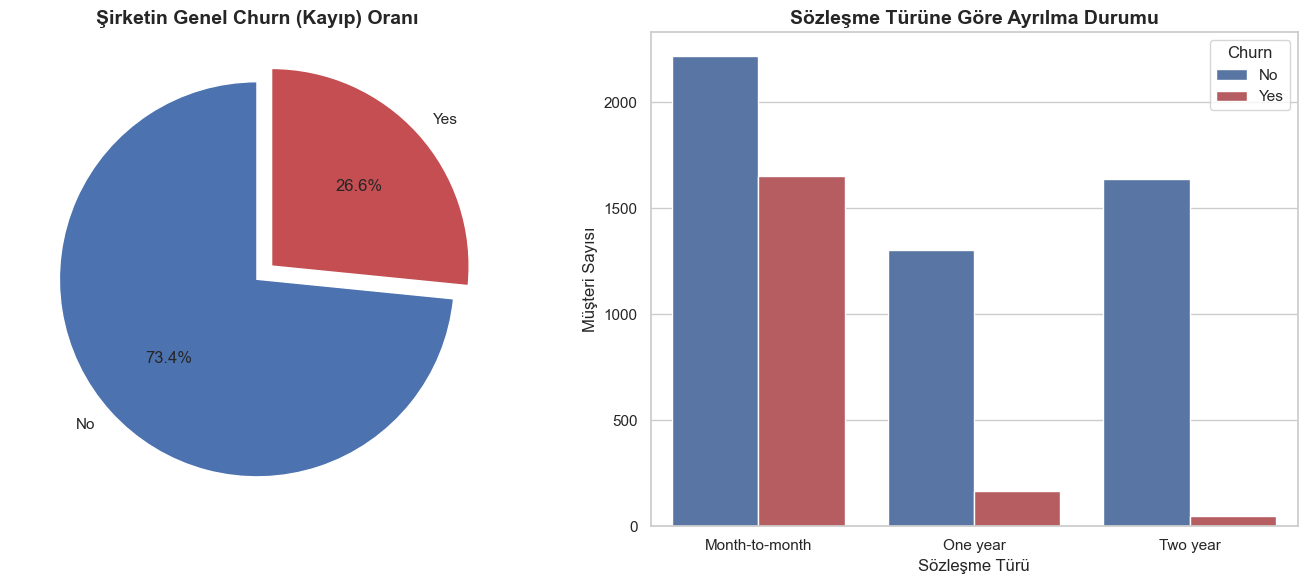

GRAFİK YORUMU:
- Şirketin genel müşteri kayıp (Churn) oranı yaklaşık %26.6'dır.
- 'Aydan aya (Month-to-month)' sözleşmesi olan müşterilerin ayrılma eğilimi, 1 veya 2 yıllık uzun vadeli taahhüdü olan müşterilere kıyasla çok daha yüksektir.


In [82]:
# Grafiklerin daha şık ve profesyonel görünmesi için bir tema seçiyoruz
sns.set_theme(style="whitegrid")

# Yan yana iki grafik çizeceğimiz geniş bir tuval oluşturuyoruz
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. GRAFİK: Genel Churn Oranı (Pasta Grafiği)
# 'Churn Label' yerine 'Churn' kullanıyoruz
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#C44E52'], explode=(0, 0.1))
axes[0].set_title('Şirketin Genel Churn (Kayıp) Oranı', fontsize=14, fontweight='bold')

# 2. GRAFİK: Sözleşme Türüne (Contract) Göre Churn Dağılımı (Sütun Grafiği)
# 'Churn Label' yerine 'Churn' kullanıyoruz
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1], palette=['#4C72B0', '#C44E52'])
axes[1].set_title('Sözleşme Türüne Göre Ayrılma Durumu', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sözleşme Türü', fontsize=12)
axes[1].set_ylabel('Müşteri Sayısı', fontsize=12)

# Ekrana temiz bir şekilde basıyoruz
plt.tight_layout()
plt.show()

# --- YORUM ÇIKTISI ---
print("GRAFİK YORUMU:")
print("- Şirketin genel müşteri kayıp (Churn) oranı yaklaşık %26.6'dır.")
print("- 'Aydan aya (Month-to-month)' sözleşmesi olan müşterilerin ayrılma eğilimi, 1 veya 2 yıllık uzun vadeli taahhüdü olan müşterilere kıyasla çok daha yüksektir.")

#### 5.2. İnternet Altyapısının Müşteri Kaybına Etkisi

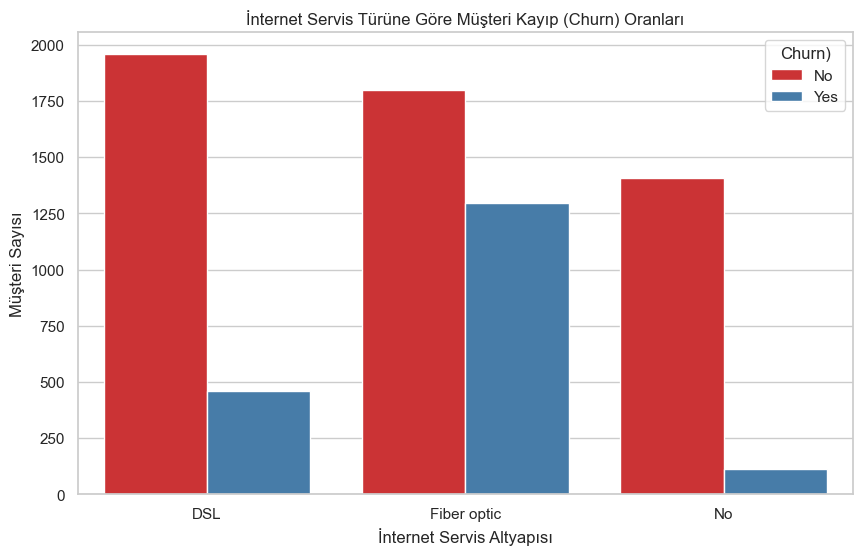

GRAFİK YORUMU:
- Fiber optik altyapısı kullanan müşterilerin ayrılma oranı, DSL veya internet kullanmayanlara göre belirgin şekilde daha yüksektir.
- Fiber hizmetinin kalitesinde veya fiyatlandırmasında yaşanan sorunlar müşteri kaybını tetikliyor olabilir.


In [83]:
# İnternet Servis Türüne Göre Müşteri Kayıp Oranlarına Bakalım.
plt.figure(figsize=(10, 6))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set1')
plt.title('İnternet Servis Türüne Göre Müşteri Kayıp (Churn) Oranları')
plt.xlabel('İnternet Servis Altyapısı')
plt.ylabel('Müşteri Sayısı')

# Ekiplerin net görmesi için lejantı düzenleyelim
plt.legend(title='Churn)', labels=['No', 'Yes'])
plt.show()

# --- YORUM ÇIKTISI ---
print("GRAFİK YORUMU:")
print("- Fiber optik altyapısı kullanan müşterilerin ayrılma oranı, DSL veya internet kullanmayanlara göre belirgin şekilde daha yüksektir.")
print("- Fiber hizmetinin kalitesinde veya fiyatlandırmasında yaşanan sorunlar müşteri kaybını tetikliyor olabilir.")

#### 5.3. Teknik Destek Hizmetinin Müşteri Sadakatine Etkisi

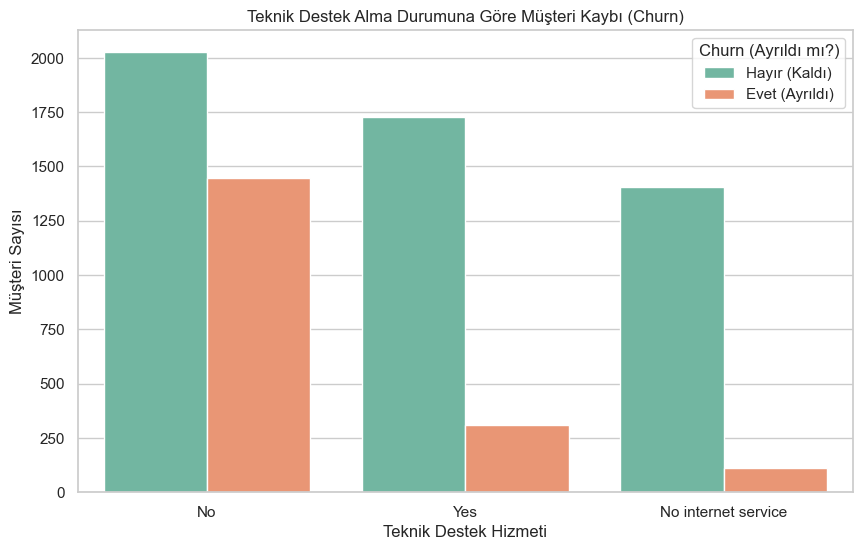

GRAFİK YORUMU:
- Teknik destek almayan müşterilerde şirketi terk etme (Churn) durumu en yüksek seviyededir.
- Teknik destek alan müşterilerin sadakati yüksek görünmektedir; bu hizmeti yaygınlaştırmak Churn oranını düşürebilir.


In [84]:
# Teknik Destek Alma Durumuna Göre Müşteri Kaybı 
plt.figure(figsize=(10, 6))
sns.countplot(x='TechSupport', hue='Churn', data=df, palette='Set2')
plt.title('Teknik Destek Alma Durumuna Göre Müşteri Kaybı (Churn)')
plt.xlabel('Teknik Destek Hizmeti')
plt.ylabel('Müşteri Sayısı')

plt.legend(title='Churn (Ayrıldı mı?)', labels=['Hayır (Kaldı)', 'Evet (Ayrıldı)'])
plt.show()

# --- YORUM ÇIKTISI ---
print("GRAFİK YORUMU:")
print("- Teknik destek almayan müşterilerde şirketi terk etme (Churn) durumu en yüksek seviyededir.")
print("- Teknik destek alan müşterilerin sadakati yüksek görünmektedir; bu hizmeti yaygınlaştırmak Churn oranını düşürebilir.")

#### 5.4. Aylık Fatura Ücreti ve Churn İlişkisi

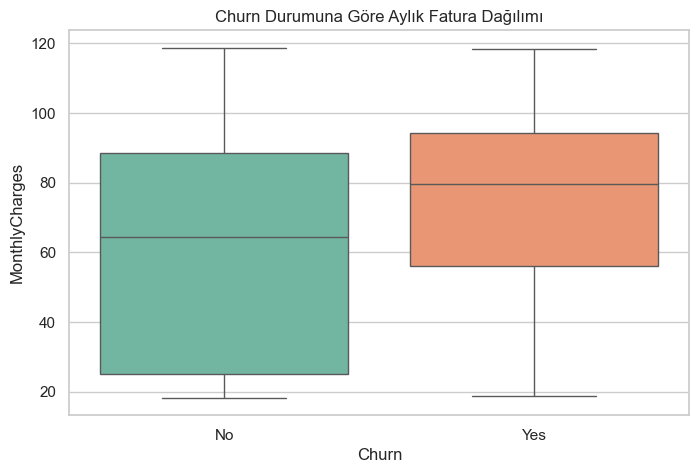

GRAFİK YORUMU:
- Ayrılan (Yes) müşterilerin aylık fatura ortalamaları ve medyan değeri, şirkette kalan müşterilere göre daha yüksektir.
- Yüksek aylık maliyetler, müşterilerin alternatif servislere yönelmesinde kritik bir faktör olarak göze çarpmaktadır.


In [85]:
#Churn Durumuna Göre Aylık Fatura Dağılımına Bakalım.
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2', hue='Churn', legend=False)
plt.title('Churn Durumuna Göre Aylık Fatura Dağılımı')
plt.show()

# --- YORUM ÇIKTISI ---
print("GRAFİK YORUMU:")
print("- Ayrılan (Yes) müşterilerin aylık fatura ortalamaları ve medyan değeri, şirkette kalan müşterilere göre daha yüksektir.")
print("- Yüksek aylık maliyetler, müşterilerin alternatif servislere yönelmesinde kritik bir faktör olarak göze çarpmaktadır.")

### 6. Makine Öğrenmesi ile Churn Tahmini (XGBoost & SMOTE)

In [86]:
# --- 1. ADIM: Temizlik ---
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)

# --- 2. ADIM: ÖZELLİK MÜHENDİSLİĞİ (Zeki Sütunlar) ---
# Bağlılık/Maliyet oranı
df['Tenure_to_MonthlyCharges'] = df['tenure'] / df['MonthlyCharges']

# Toplam ekstra hizmet sayısı
hizmetler = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
             'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Total_Services_Count'] = (df[hizmetler] != 'No').sum(axis=1)

# --- 3. ADIM: Hedef (y) ve Özellik (X) Ayrımı ---
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_encoded = pd.get_dummies(X, drop_first=True)

# --- 4. ADIM: Veriyi Bölme (80 Eğitim - 10 Validasyon - 10 Test) ---
X_train, X_temp, y_train, y_temp = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# --- 5. ADIM: SMOTE (Dengeyi Sağlıyoruz) ---
# SMOTE'u tekrar aktif ettik! Sadece eğitim verisine uyguluyoruz.
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# --- 6. ADIM: YENİ MODEL - XGBoost ---
xgb_model = XGBClassifier(
    random_state=42,
    learning_rate=0.03,    # Düşük öğrenme hızı (daha dikkatli)
    max_depth=5,           # Ağaç derinliği
    n_estimators=300,      # Ağaç sayısı
    subsample=0.8,         # Verinin %80'iyle öğren
    colsample_bytree=0.8,  # Sütunların %80'iyle öğren
    eval_metric='logloss'
)

# Modeli SMOTE'lu, dengeli verilerle eğitiyoruz
xgb_model.fit(X_train_smote, y_train_smote)

# Validasyon setiyle tahmin yapıyoruz
y_pred = xgb_model.predict(X_val)

# --- SONUÇLAR ---
print("\n--- XGBOOST (SMOTE + FEATURE ENGINEERING) BAŞARI KARNESİ ---")
print(classification_report(y_val, y_pred))

accuracy = accuracy_score(y_val, y_pred) * 100
print(f"\nGenel Doğruluk Oranı (Accuracy): %{accuracy:.2f}")


--- XGBOOST (SMOTE + FEATURE ENGINEERING) BAŞARI KARNESİ ---
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       516
           1       0.56      0.60      0.58       187

    accuracy                           0.77       703
   macro avg       0.70      0.71      0.71       703
weighted avg       0.77      0.77      0.77       703


Genel Doğruluk Oranı (Accuracy): %76.67


### 7. Modelin Kaydedilmesi

In [ ]:
# Modeli kaydediyoruz
joblib.dump(xgb_model, 'churn_model.pkl')

# Sütun isimlerini kaydediyoruz
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(list(X_encoded.columns), f)

print("Güncel model dosyaları başarıyla oluşturuldu!")